# Reading test and train data

In [1]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandasql as ps

df1 = pd.read_csv('test-data.csv', encoding = 'utf-8')
df2 = pd.read_csv('train-data.csv', encoding = 'utf-8')

print(df1.head())
print(df2.head())

           state   latitude   longitude    zip_code        id  \
0     Washington  47.603122 -122.333253       98104       c:1   
1     California        NaN         NaN  94105-1503   c:10015   
2     California  37.796843 -122.400346       94105   c:10018   
3  Massachusetts  42.018989  -71.007822        2379  c:100238   
4     California  37.775196 -122.419204  94103-2812    c:1003   

               city             name     status  labels  founded_at  ...  \
0           Seattle         Wetpaint  operating       1  10/17/2005  ...   
1     San Francisco           Fitbit  operating       1   10/1/2007  ...   
2     San Francisco       Demandbase  operating       1    1/1/2006  ...   
3  West Bridgewater  Cardiosolutions  operating       1    1/1/2006  ...   
4     San Francisco        Wikinvest  operating       1    1/1/2006  ...   

   is_othercategory object_id has_VC  has_angel  has_roundA  has_roundB  \
0                 0       c:1      0          0           1           1   
1 

# DC 1: Combining both data into a single csv data

In [2]:
combined_final_df = pd.concat([df1, df2], ignore_index=True)

# DC 2: Merging state_code and state_code.1 columns and dropping state_code.1

In [3]:
combined_final_df['state_code'] = combined_final_df['state_code'].fillna(combined_final_df['state_code.1'])

combined_final_df.drop(columns=['state_code.1'], inplace=True)

# DC 3: Remove duplicate columns

In [4]:
duplicate_columns = []

for col1 in combined_final_df.columns:
    for col2 in combined_final_df.columns:
        if col1 != col2 and combined_final_df[col1].equals(combined_final_df[col2]):
            if col2 not in duplicate_columns:
                duplicate_columns.append(col2)

print(duplicate_columns)

['object_id', 'id']


In [5]:
combined_final_df.drop(columns=['object_id'], inplace=True)

# DC 4: Mapping State with given State code

In [7]:
state_mapping = {
    'AL': 'Alabama',
    'AK': 'Alaska',
    'AZ': 'Arizona',
    'AR': 'Arkansas',
    'CA': 'California',
    'CO': 'Colorado',
    'CT': 'Connecticut',
    'DC': 'Washington DC',
    'DE': 'Delaware',
    'FL': 'Florida',
    'GA': 'Georgia',
    'HI': 'Hawaii',
    'ID': 'Idaho',
    'IL': 'Illinois',
    'IN': 'Indiana',
    'IA': 'Iowa',
    'KS': 'Kansas',
    'KY': 'Kentucky',
    'LA': 'Louisiana',
    'ME': 'Maine',
    'MD': 'Maryland',
    'MA': 'Massachusetts',
    'MI': 'Michigan',
    'MN': 'Minnesota',
    'MS': 'Mississippi',
    'MO': 'Missouri',
    'MT': 'Montana',
    'NE': 'Nebraska',
    'NV': 'Nevada',
    'NH': 'New Hampshire',
    'NJ': 'New Jersey',
    'NM': 'New Mexico',
    'NY': 'New York',
    'NC': 'North Carolina',
    'ND': 'North Dakota',
    'OH': 'Ohio',
    'OK': 'Oklahoma',
    'OR': 'Oregon',
    'PA': 'Pennsylvania',
    'RI': 'Rhode Island',
    'SC': 'South Carolina',
    'SD': 'South Dakota',
    'TN': 'Tennessee',
    'TX': 'Texas',
    'UT': 'Utah',
    'VT': 'Vermont',
    'VA': 'Virginia',
    'WA': 'Washington',
    'WV': 'West Virginia',
    'WI': 'Wisconsin',
    'WY': 'Wyoming'
}

combined_final_df['state'] = combined_final_df['state_code'].map(state_mapping)

print(combined_final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491 entries, 0 to 5490
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   state                     5491 non-null   object 
 1   latitude                  2720 non-null   float64
 2   longitude                 2720 non-null   float64
 3   zip_code                  5491 non-null   object 
 4   id                        5491 non-null   object 
 5   city                      5491 non-null   object 
 6   name                      5491 non-null   object 
 7   status                    5491 non-null   object 
 8   labels                    5491 non-null   int64  
 9   founded_at                5491 non-null   object 
 10  closed_at                 419 non-null    object 
 11  first_funding_at          5491 non-null   object 
 12  last_funding_at           5491 non-null   object 
 13  age_first_funding_year    5491 non-null   float64
 14  age_last

# DC 5: mapping missing lat/long values from state

In [8]:
state_coordinates = {
    'Alabama': (32.806671, -86.791130),
    'Alaska': (61.370716, -152.404419),
    'Arizona': (33.729759, -111.431221),
    'Arkansas': (34.969704, -92.373123),
    'California': (36.116203, -119.681564),
    'Colorado': (39.059811, -105.311104),
    'Connecticut': (41.597782, -72.755371),
    'Washington DC': (38.8951,-77.0364),
    'Delaware': (39.318523, -75.507141),
    'Florida': (27.766279, -81.686783),
    'Georgia': (33.040619, -83.643074),
    'Hawaii': (21.094318, -157.498337),
    'Idaho': (44.240459, -114.478828),
    'Illinois': (40.349457, -88.986137),
    'Indiana': (39.849426, -86.258278),
    'Iowa': (42.011539, -93.210526),
    'Kansas': (38.526600, -96.726486),
    'Kentucky': (37.668140, -84.670067),
    'Louisiana': (31.169546, -91.867805),
    'Maine': (44.693947, -69.381927),
    'Maryland': (39.063946, -76.802101),
    'Massachusetts': (42.230171, -71.530106),
    'Michigan': (43.326618, -84.536095),
    'Minnesota': (45.694454, -93.900192),
    'Mississippi': (32.741646, -89.678696),
    'Missouri': (38.456085, -92.288368),
    'Montana': (46.921925, -110.454353),
    'Nebraska': (41.125370, -98.268082),
    'Nevada': (38.313515, -117.055374),
    'New Hampshire': (43.452492, -71.563896),
    'New Jersey': (40.298904, -74.521011),
    'New Mexico': (34.840515, -106.248482),
    'New York': (42.165726, -74.948051),
    'North Carolina': (35.630066, -79.806419),
    'North Dakota': (47.528912, -99.784012),
    'Ohio': (40.388783, -82.764915),
    'Oklahoma': (35.565342, -96.928917),
    'Oregon': (44.572021, -122.070938),
    'Pennsylvania': (40.590752, -77.209755),
    'Rhode Island': (41.680893, -71.511780),
    'South Carolina': (33.856892, -80.945007),
    'South Dakota': (44.299782, -99.438828),
    'Tennessee': (35.747845, -86.692345),
    'Texas': (31.054487, -97.563461),
    'Utah': (40.150032, -111.862434),
    'Vermont': (44.045876, -72.710686),
    'Virginia': (37.769337, -78.169968),
    'Washington': (47.400902, -121.490494),
    'West Virginia': (38.491226, -80.954803),
    'Wisconsin': (44.268543, -89.616508),
    'Wyoming': (42.755966, -107.302490)
}

def fill_lat_lon(row):
    if pd.isnull(row['latitude']) or pd.isnull(row['longitude']):
        state_name = row['state']
        if state_name in state_coordinates:
            row['latitude'], row['longitude'] = state_coordinates[state_name]
    return row

combined_final_df = combined_final_df.apply(fill_lat_lon, axis=1)
print(combined_final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491 entries, 0 to 5490
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   state                     5491 non-null   object 
 1   latitude                  5491 non-null   float64
 2   longitude                 5491 non-null   float64
 3   zip_code                  5491 non-null   object 
 4   id                        5491 non-null   object 
 5   city                      5491 non-null   object 
 6   name                      5491 non-null   object 
 7   status                    5491 non-null   object 
 8   labels                    5491 non-null   int64  
 9   founded_at                5491 non-null   object 
 10  closed_at                 419 non-null    object 
 11  first_funding_at          5491 non-null   object 
 12  last_funding_at           5491 non-null   object 
 13  age_first_funding_year    5491 non-null   float64
 14  age_last

# DC 6: Deleting unused columns

In [9]:
combined_final_df.drop(columns=['has_roundD','id', 'labels', 'zip_code', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'closed_at', 'Unnamed: 0', 'Unnamed: 6', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory'], inplace=True)

# Dataframe structure before removing duplicate rows

In [10]:
print(combined_final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491 entries, 0 to 5490
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   state                     5491 non-null   object 
 1   latitude                  5491 non-null   float64
 2   longitude                 5491 non-null   float64
 3   city                      5491 non-null   object 
 4   name                      5491 non-null   object 
 5   status                    5491 non-null   object 
 6   founded_at                5491 non-null   object 
 7   first_funding_at          5491 non-null   object 
 8   last_funding_at           5491 non-null   object 
 9   age_first_funding_year    5491 non-null   float64
 10  age_last_funding_year     5491 non-null   float64
 11  age_first_milestone_year  4426 non-null   float64
 12  age_last_milestone_year   4426 non-null   float64
 13  relationships             5491 non-null   int64  
 14  funding_

# DC 7: Removing duplicate row values based on company name

In [11]:
df_no_duplicates = combined_final_df.drop_duplicates(subset=['name'])

# DC 8: Remove rows with missing values for age_first_milestone_year

In [12]:
missing_company = df_no_duplicates['age_first_milestone_year'].isnull().any()
print(missing_company)

True


In [13]:
missing_company_count = df_no_duplicates['age_first_milestone_year'].isnull().sum()
print(missing_company_count)

1065


In [15]:
df_removed_missing_names = df_no_duplicates.dropna(subset=['age_first_milestone_year'])

df_removed_missing_names.reset_index(drop=True, inplace=True)

# DC 9: Rounding off decimal values to .2f

In [16]:
df_removed_missing_names.loc[:, 'age_first_funding_year'] = df_removed_missing_names['age_first_funding_year'].round(2)
df_removed_missing_names.loc[:, 'age_last_funding_year'] = df_removed_missing_names['age_last_funding_year'].round(2)
df_removed_missing_names.loc[:, 'age_first_milestone_year'] = df_removed_missing_names['age_first_milestone_year'].round(2)
df_removed_missing_names.loc[:, 'age_last_milestone_year'] = df_removed_missing_names['age_last_milestone_year'].round(2)

df_removed_missing_names['avg_participants'] = df_removed_missing_names['avg_participants'].round(2)

/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/2186136034.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_removed_missing_names['avg_participants'] = df_removed_missing_names['avg_participants'].round(2)


# DC 10: Adding a new column "id" and giving values to it in our df

In [17]:
df_removed_missing_names['id'] = pd.Series(range(1, len(df_removed_missing_names) + 1)).astype(int)
print(df_removed_missing_names.tail())

           state   latitude   longitude           city                name  \
4419  California  37.758062 -122.418642  San Francisco             Fluther   
4420  California  41.789420  -87.596232  San Francisco  ReTel Technologies   
4421    New York  40.740441  -73.993376       New York            ShopWiki   
4422    New York  40.739010  -73.997259       New York           DailyBurn   
4423  California  37.557637 -122.285714      Palo Alto              Zimbra   

        status founded_at first_funding_at last_funding_at  \
4419  acquired   1/1/2007        9/21/2009       9/21/2009   
4420  acquired  10/1/2007         8/6/2009       12/2/2009   
4421  acquired   6/1/2005         7/1/2006        7/1/2006   
4422  acquired  10/1/2007         5/1/2008       5/26/2009   
4423  acquired   1/1/2003         4/1/2006        4/1/2006   

      age_first_funding_year  ...  state_code  category_code  has_VC  \
4419                    2.72  ...          CA            web       0   
4420          

/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/706313193.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_removed_missing_names['id'] = pd.Series(range(1, len(df_removed_missing_names) + 1)).astype(int)


# DC 11: Finding outliers and removing them

In [18]:
numerical_columns = df_removed_missing_names.select_dtypes(include='number').columns

z_scores = stats.zscore(df_removed_missing_names[numerical_columns])

threshold = 3

outliers = (z_scores > threshold) | (z_scores < -threshold)

combined_final_df_no_outliers = df_removed_missing_names[~outliers.any(axis=1)]

print(combined_final_df_no_outliers)

           state   latitude   longitude           city                name  \
1     California  37.796843 -122.400346  San Francisco          Demandbase   
2     California  37.775196 -122.419204  San Francisco           Wikinvest   
3     California  36.116203 -119.681564  San Francisco              Jogabo   
4     California  37.384239 -122.012475      Sunnyvale             iCharts   
5       New York  42.165726  -74.948051       New York              ChatID   
...          ...        ...         ...            ...                 ...   
4419  California  37.758062 -122.418642  San Francisco             Fluther   
4420  California  41.789420  -87.596232  San Francisco  ReTel Technologies   
4421    New York  40.740441  -73.993376       New York            ShopWiki   
4422    New York  40.739010  -73.997259       New York           DailyBurn   
4423  California  37.557637 -122.285714      Palo Alto              Zimbra   

         status founded_at first_funding_at last_funding_at  \


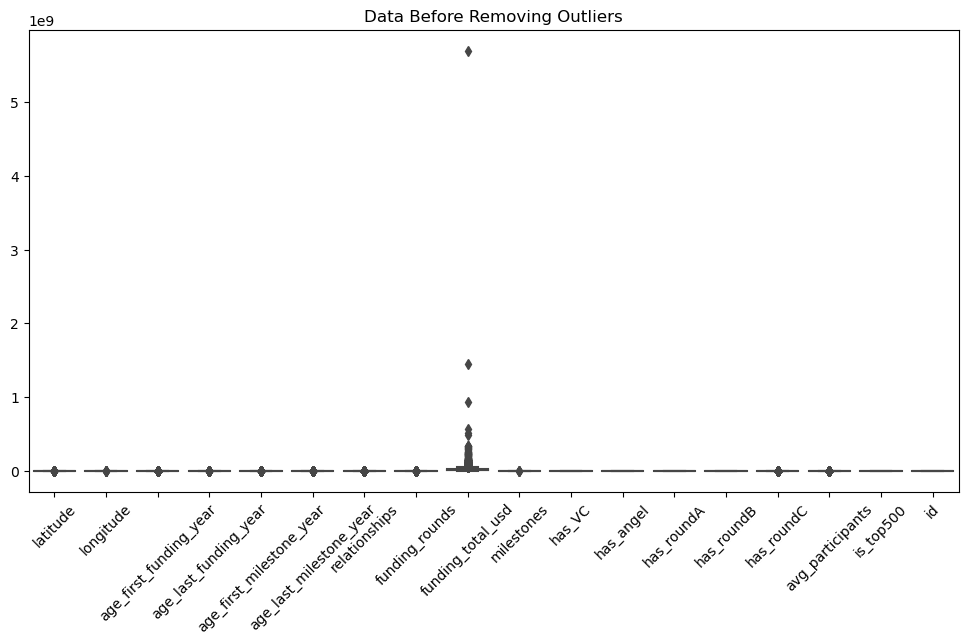

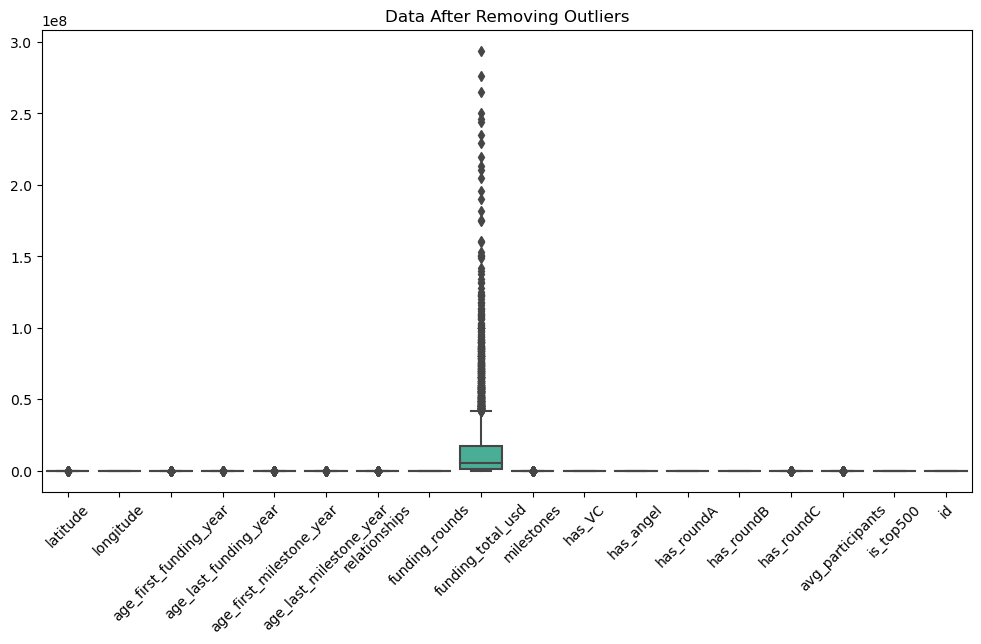

In [19]:
numeric_columns = df_removed_missing_names.select_dtypes(include=['number'])

z_scores = stats.zscore(numeric_columns)

threshold = 3

outliers = (z_scores > threshold).any(axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_columns)
plt.title('Data Before Removing Outliers')
plt.xticks(rotation=45)
plt.show()

data_without_outliers = df_removed_missing_names[~outliers]

plt.figure(figsize=(12, 6))
sns.boxplot(data=data_without_outliers.select_dtypes(include=['number']))
plt.title('Data After Removing Outliers')
plt.xticks(rotation=45)
plt.show()

# EDA 1 - Correlation matrix heatmap

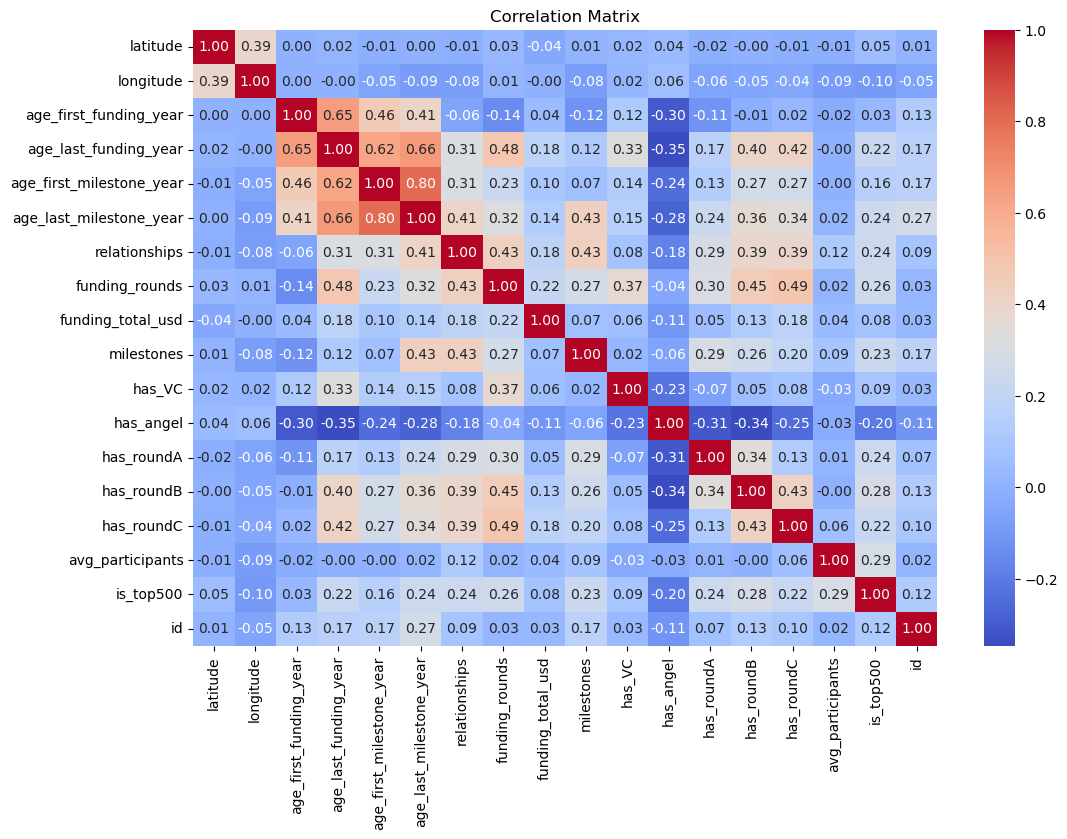

In [20]:
numeric_columns = df_removed_missing_names.select_dtypes(include=['number'])

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# EDA 2: Bar plot - relationship vs count

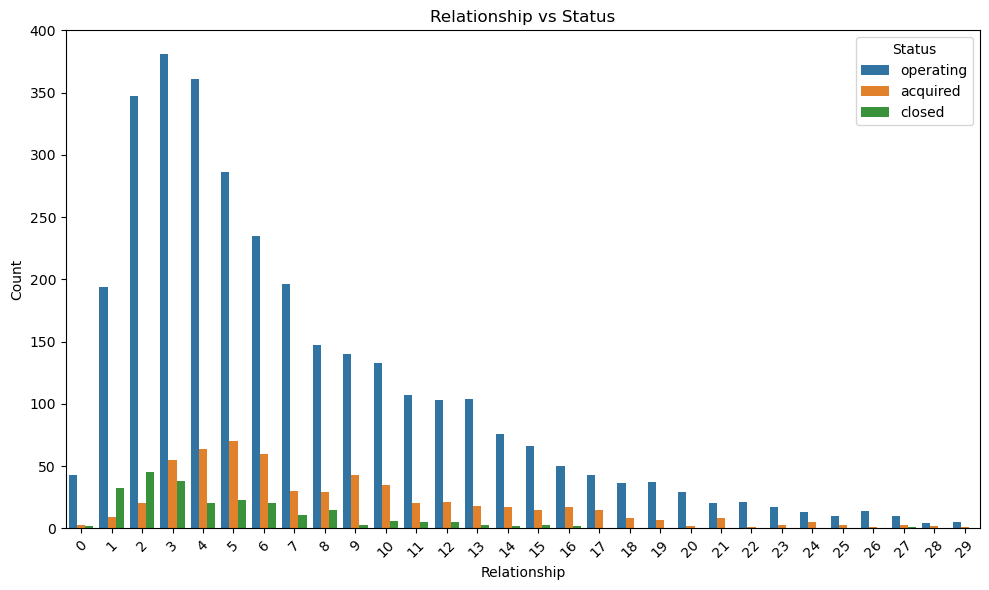

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=data_without_outliers, x='relationships', hue='status')
plt.title('Relationship vs Status')
plt.xlabel('Relationship')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

# EDA 3a: Statistics for numerical columns

In [22]:
print(data_without_outliers.describe())

          latitude    longitude  age_first_funding_year  \
count  4049.000000  4049.000000             4049.000000   
mean     38.530555  -101.669599                1.423097   
std       3.734285    21.228941                1.541479   
min      21.094318  -157.808639               -9.050000   
25%      36.116203  -119.688412                0.330000   
50%      37.779281  -117.862486                1.080000   
75%      41.597782   -75.301840                2.130000   
max      48.878479   -69.381927                6.750000   

       age_last_funding_year  age_first_milestone_year  \
count            4049.000000               4049.000000   
mean                2.905678                  2.000205   
std                 2.056246                  2.302194   
min                -9.050000                -32.020000   
25%                 1.340000                  0.500000   
50%                 2.550000                  1.690000   
75%                 4.280000                  3.290000   
max 

# EDA 3b: Statistics for categorical columns

In [23]:
print(data_without_outliers.describe(include='object'))

             state           city        name     status founded_at  \
count         4049           4049        4049       4049       4049   
unique          44            546        4049          3        716   
top     California  San Francisco  Demandbase  operating   1/1/2007   
freq          1901            644           1       3228        282   

       first_funding_at last_funding_at state_code category_code  
count              4049            4049       4049          4049  
unique             1564            1340         44            41  
top            1/1/2008        4/1/2013         CA      software  
freq                 58              29       1901           554  


# EDA 3c: Data types and missing values

In [24]:
print(data_without_outliers.dtypes)

print(data_without_outliers.isnull().sum())


state                        object
latitude                    float64
longitude                   float64
city                         object
name                         object
status                       object
founded_at                   object
first_funding_at             object
last_funding_at              object
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
state_code                   object
category_code                object
has_VC                        int64
has_angel                     int64
has_roundA                    int64
has_roundB                    int64
has_roundC                    int64
avg_participants            float64
is_top500                     int64
id                            int64
dtype: object
state         

# EDA 4: Histogram representation

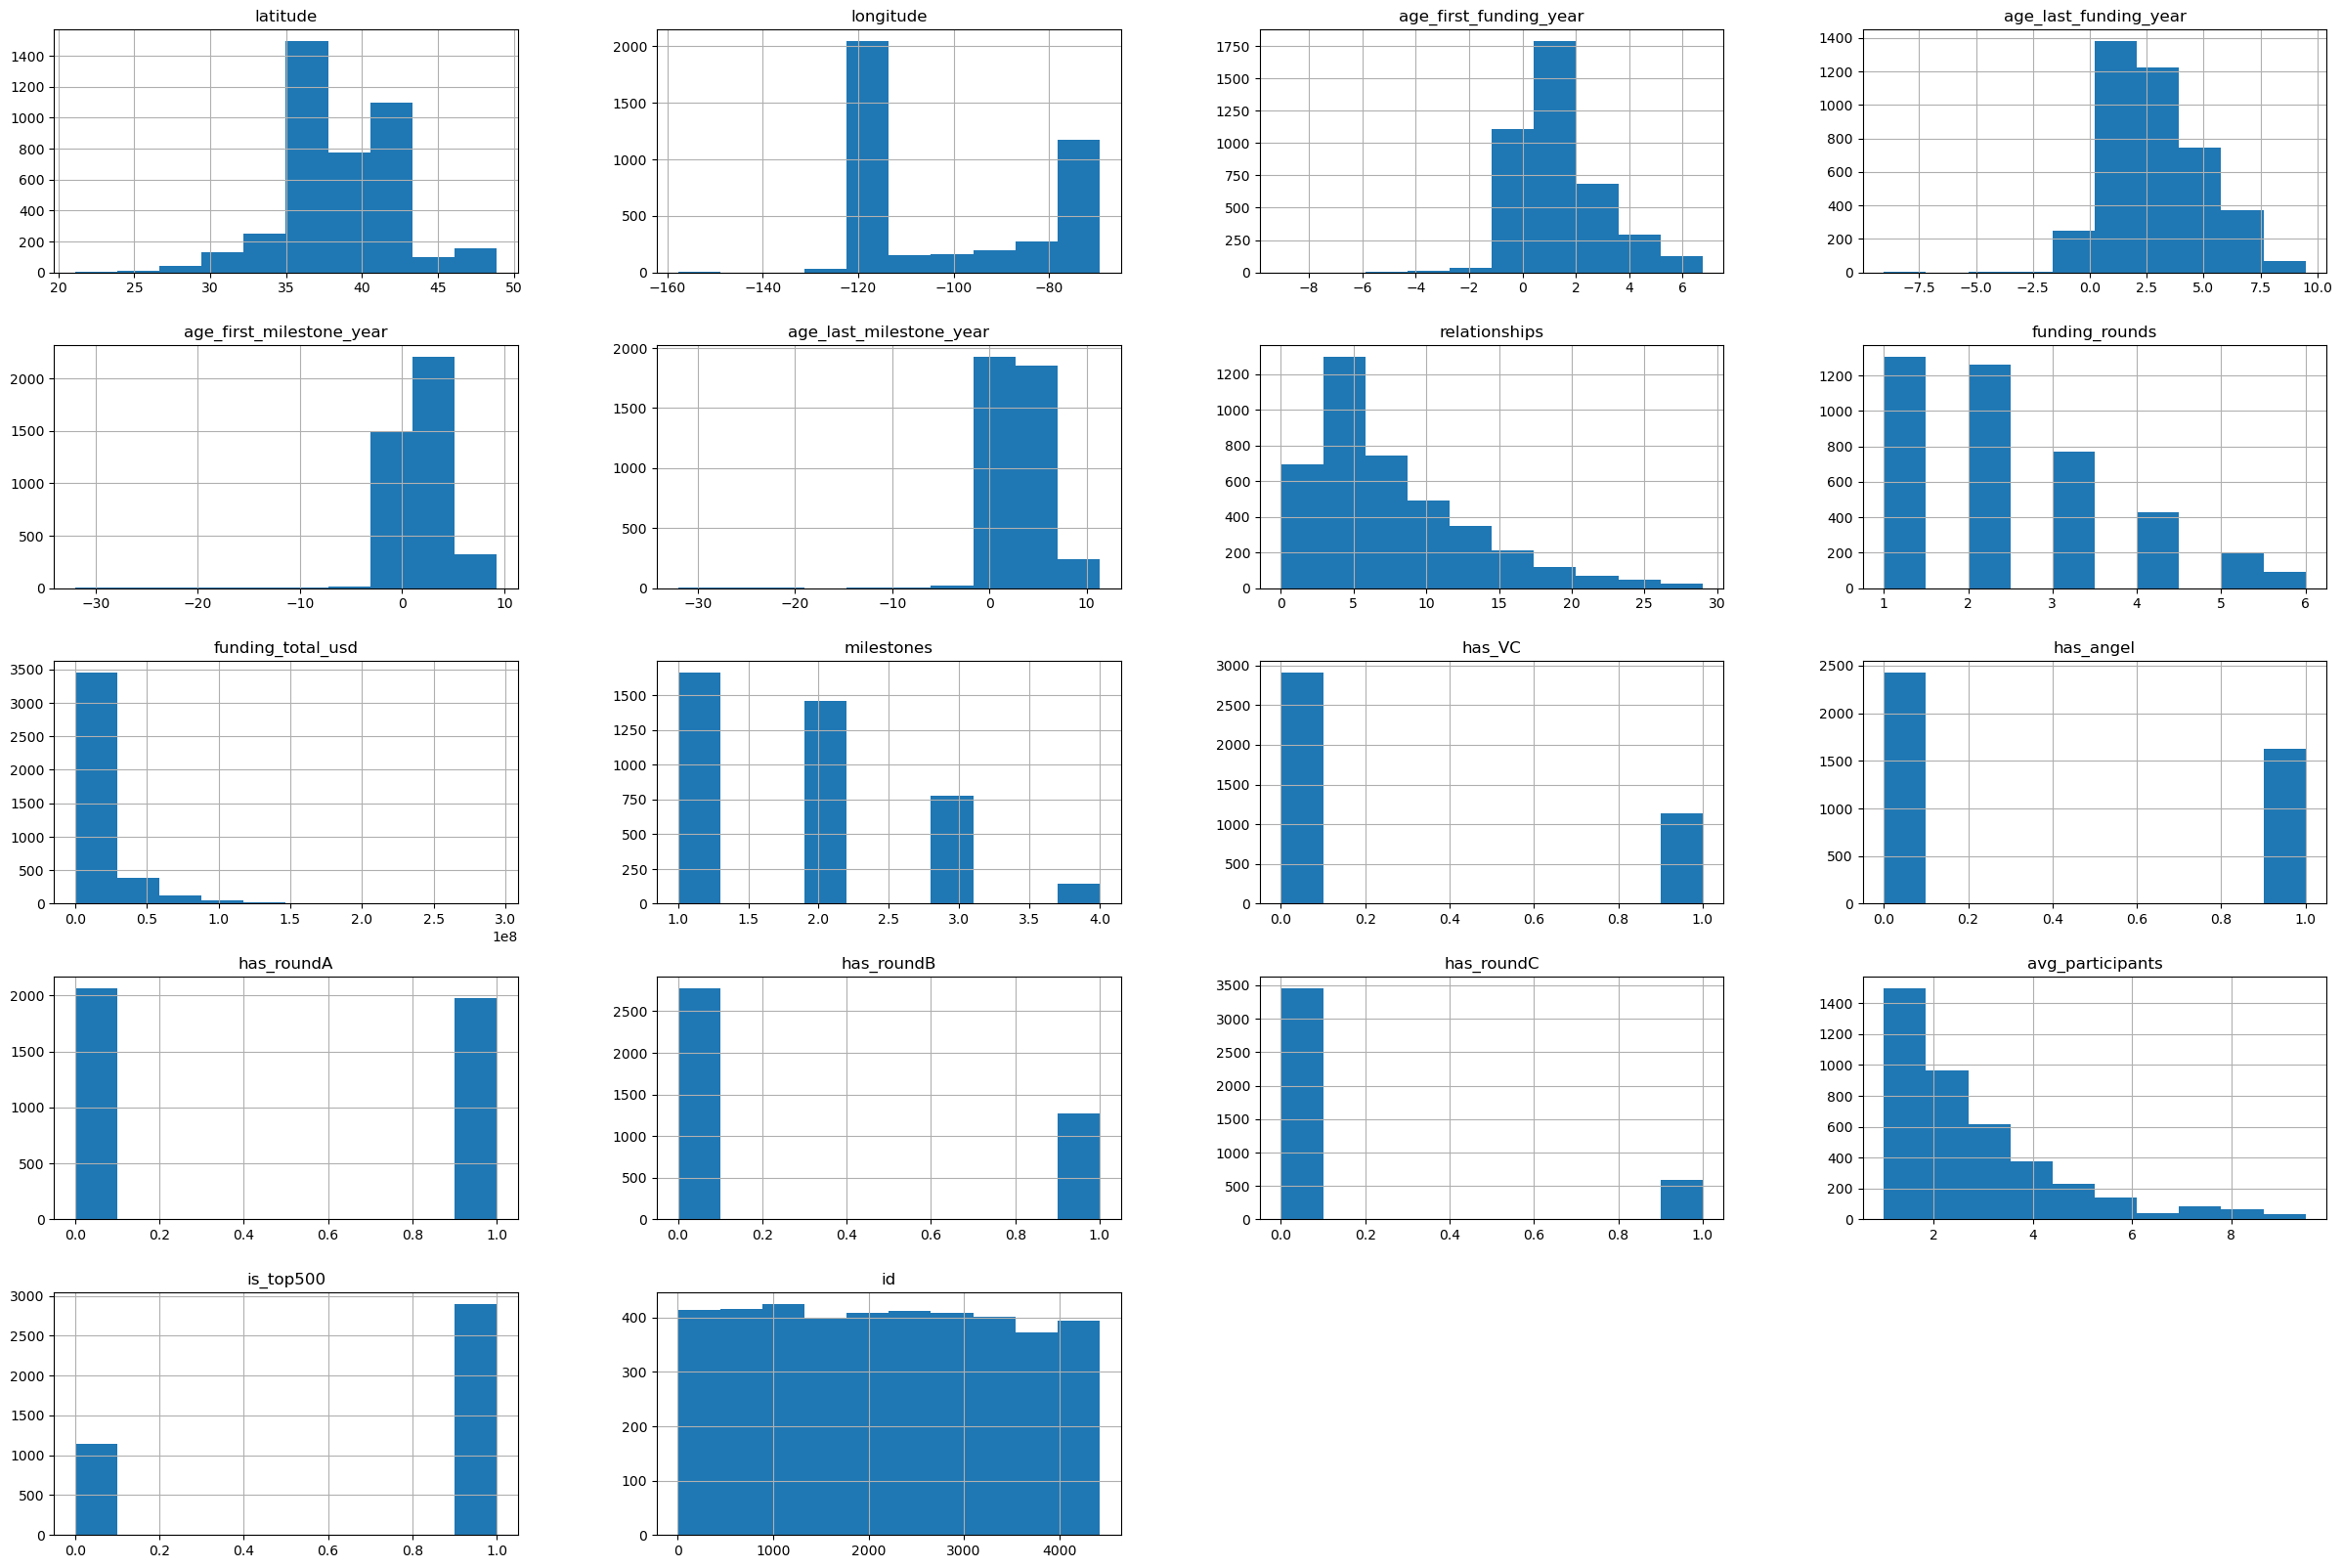

In [25]:
data_without_outliers.hist(figsize=(30, 20))
plt.show()

# EDA 5: Relationship between category_code and count

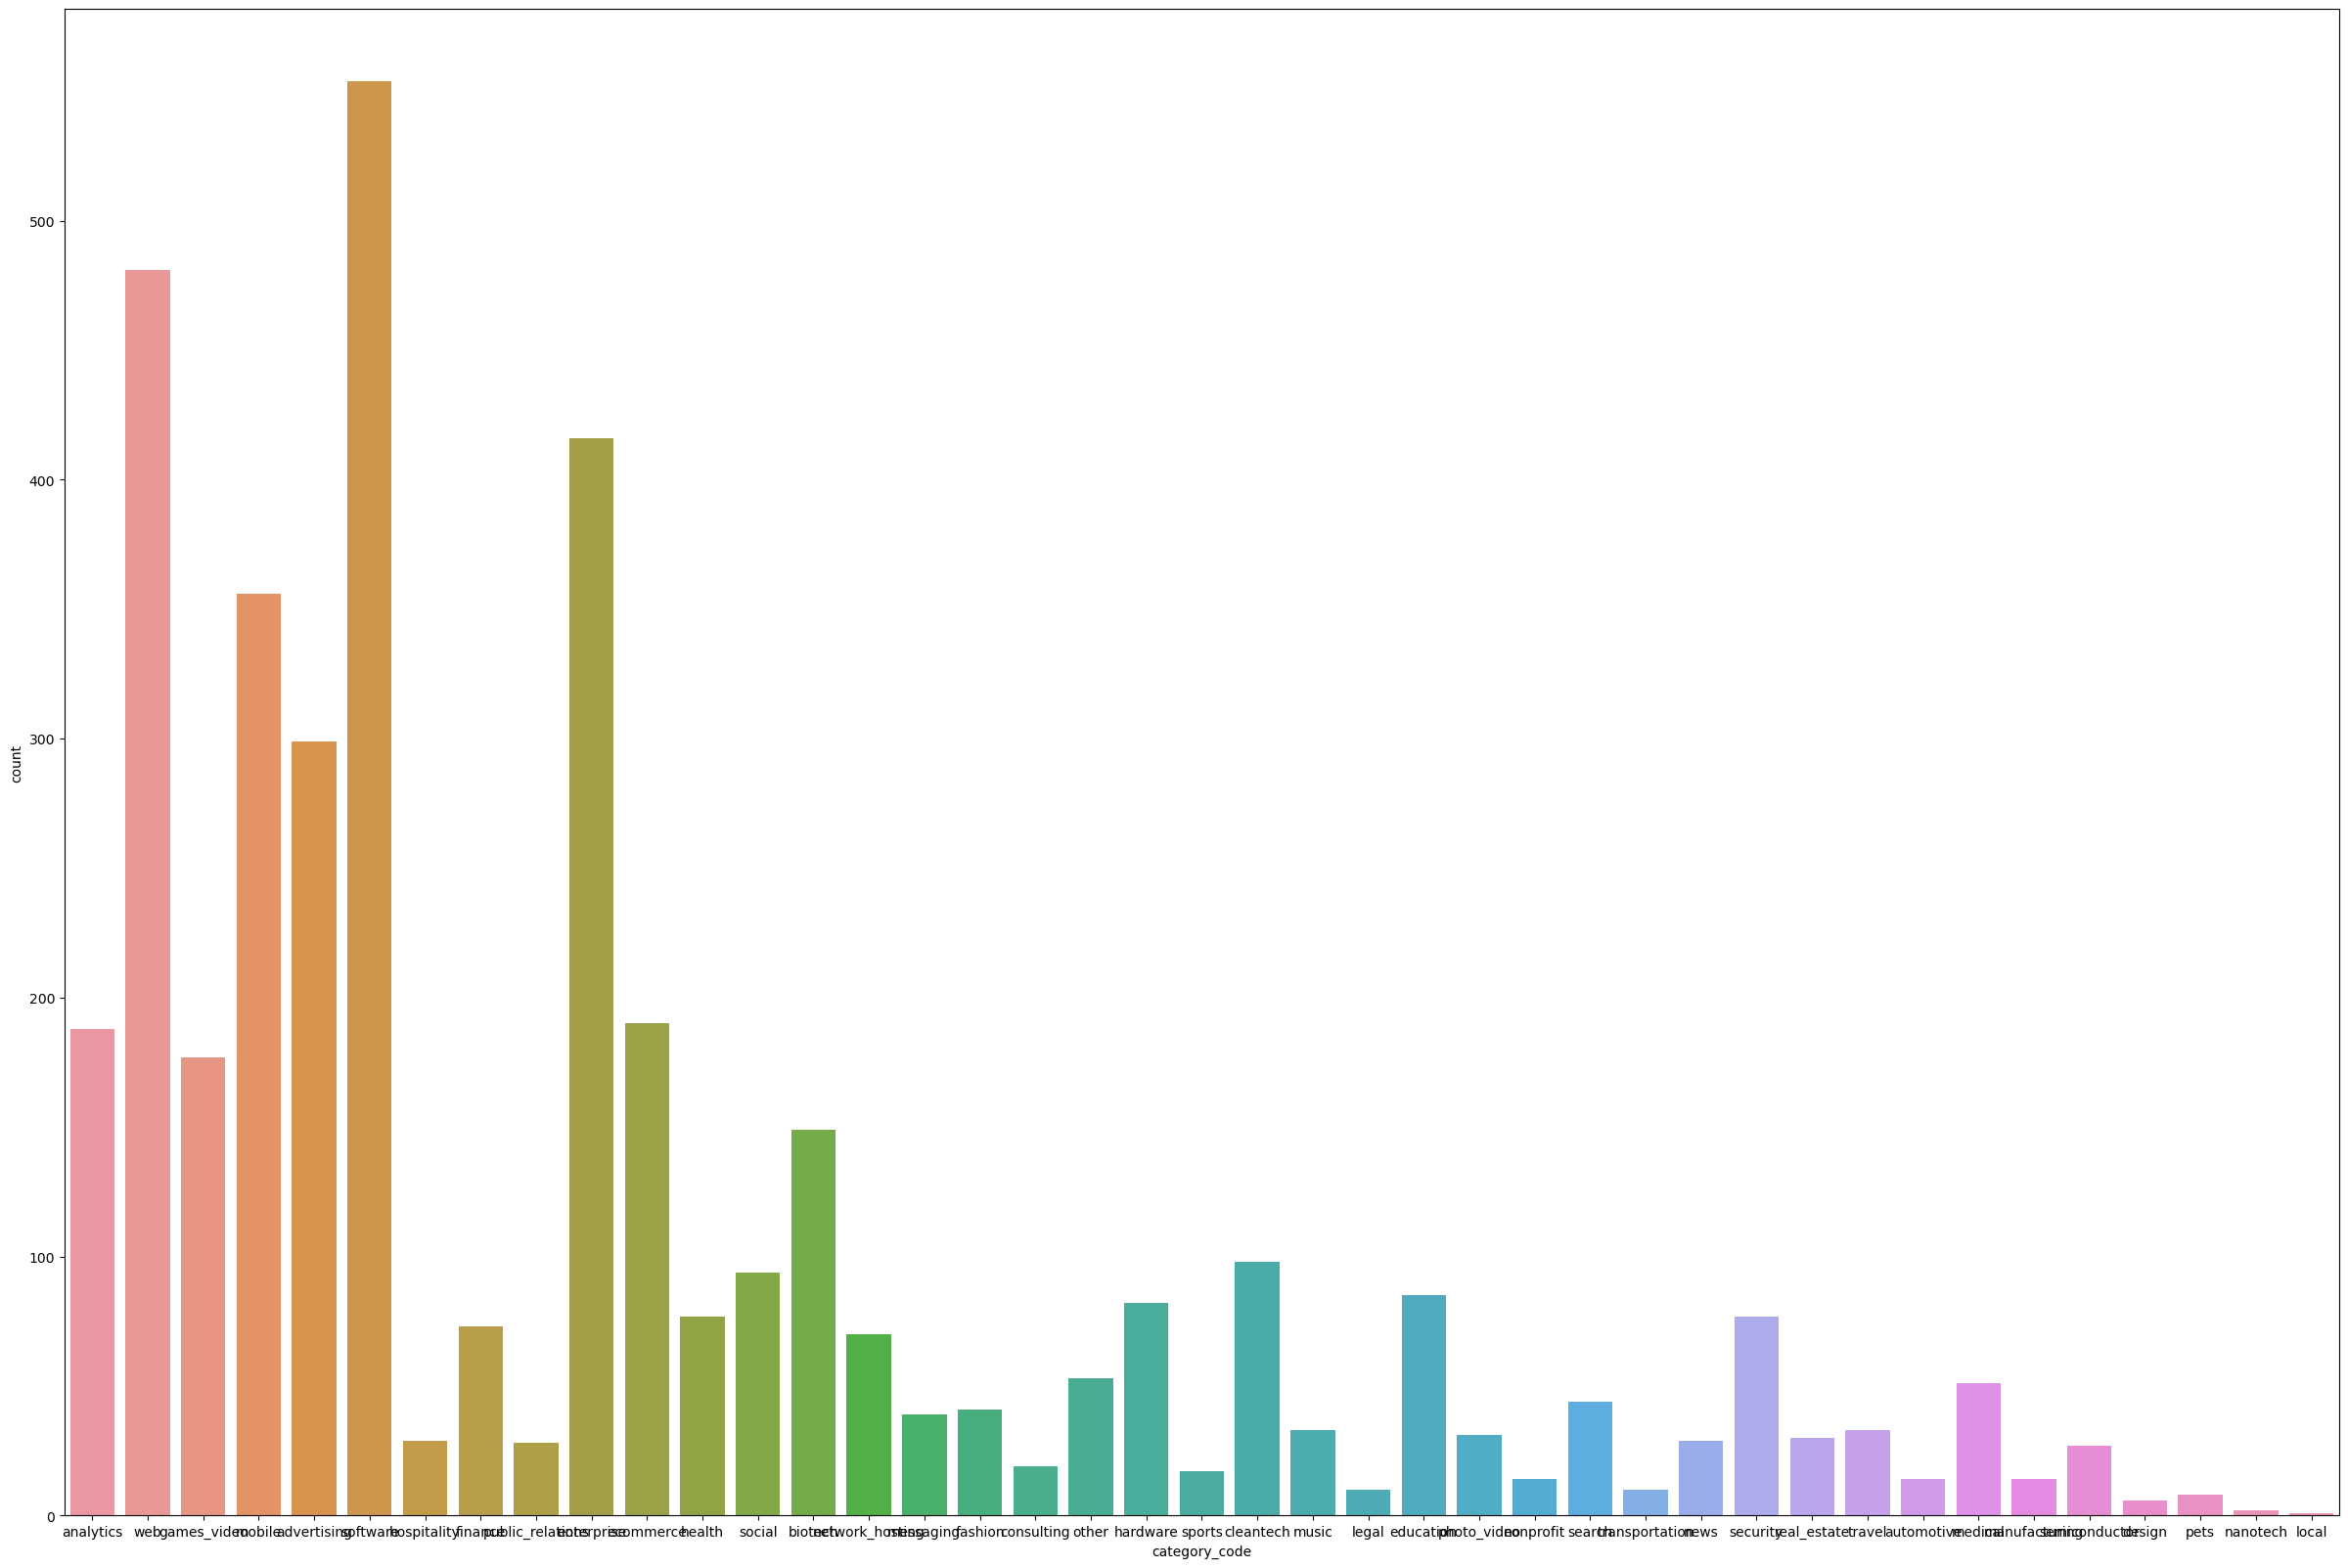

In [26]:
plt.figure(figsize=(30, 20))  
sns.countplot(x='category_code', data=data_without_outliers)
plt.show()

# EDA 6: Relationship table - milestones_group vs status

In [27]:
q2 = '''
        select milestones_group, 
               status, 
               count(*) as count
        from (
        select milestones,
               case when milestones = 0 then "0"
               when milestones between 1 and 2 then "1-2" 
               when milestones between 3 and 5 then "3-5"
               else "5+" end as milestones_group,
               status
        from data_without_outliers
        ) dt1
        group by 1,2
        order by 1
'''

milestones_df = ps.sqldf(q2, locals())
milestones_df

,milestones_group,status,count
0,1-2,acquired,374
1,1-2,closed,188
2,1-2,operating,2563
3,3-5,acquired,211
4,3-5,closed,48
5,3-5,operating,665


# EDA 7: Density of company locations on the worldmap based on lat/long

In [28]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/3043490082.py:9: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


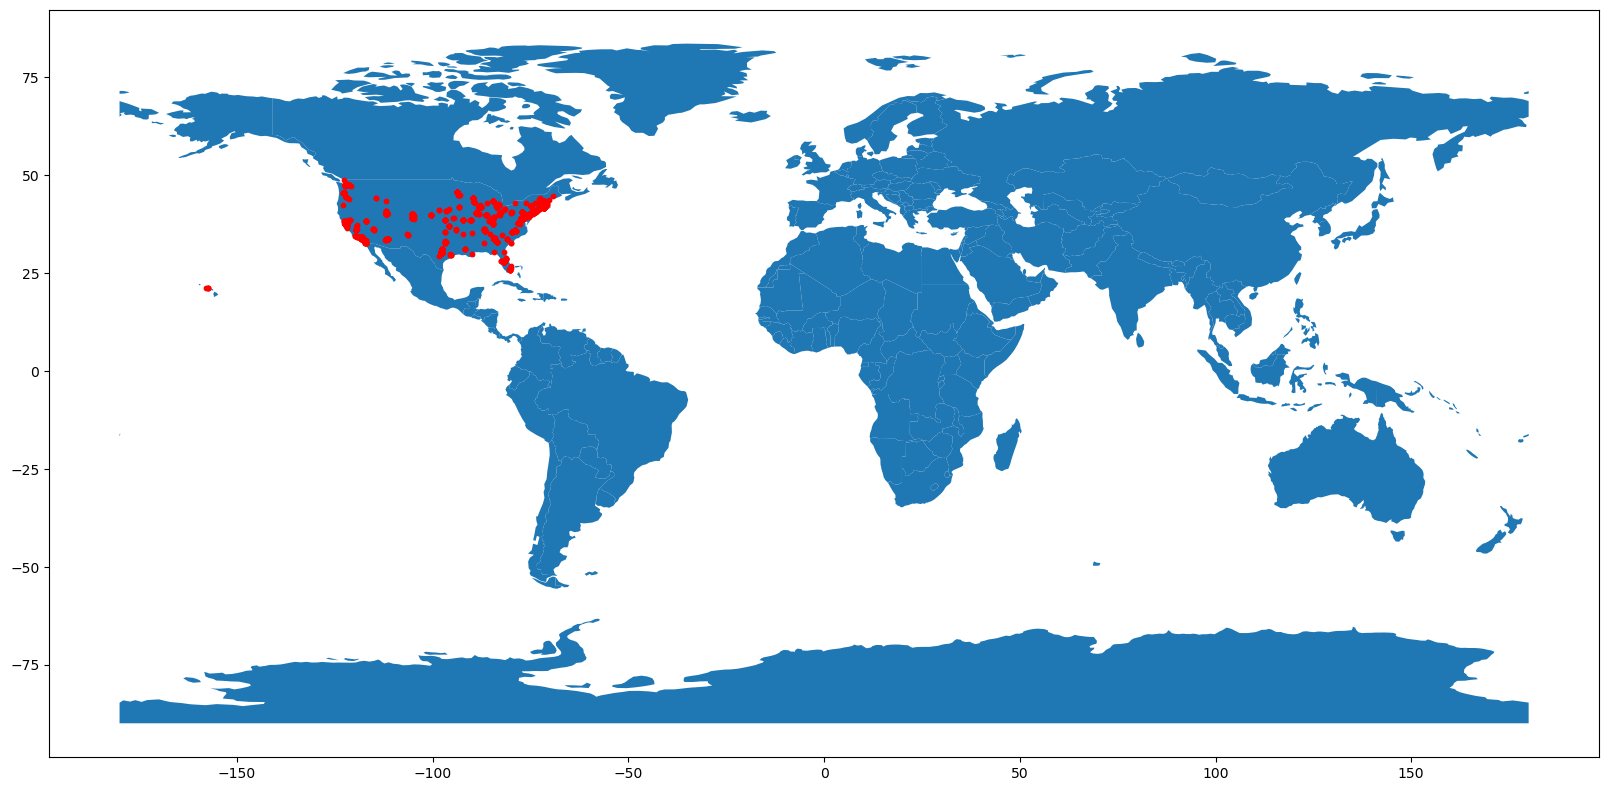

In [29]:
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame

geometry = [Point(xy) for xy in zip(data_without_outliers['longitude'], data_without_outliers['latitude'])]
gdf = GeoDataFrame(data_without_outliers, geometry=geometry)   

#this is a simple map that goes with geopandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

gdf.plot(ax=world.plot(figsize=(20, 12)), marker='o', color='red', markersize=10);

# EDA 8: Time series trends

/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/691570140.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_without_outliers['founded_at'] = pd.to_datetime(data_without_outliers['founded_at'])
/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/691570140.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_without_outliers['first_funding_at'] = pd.to_datetime(data_without_outliers['first_funding_at'])
/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/6

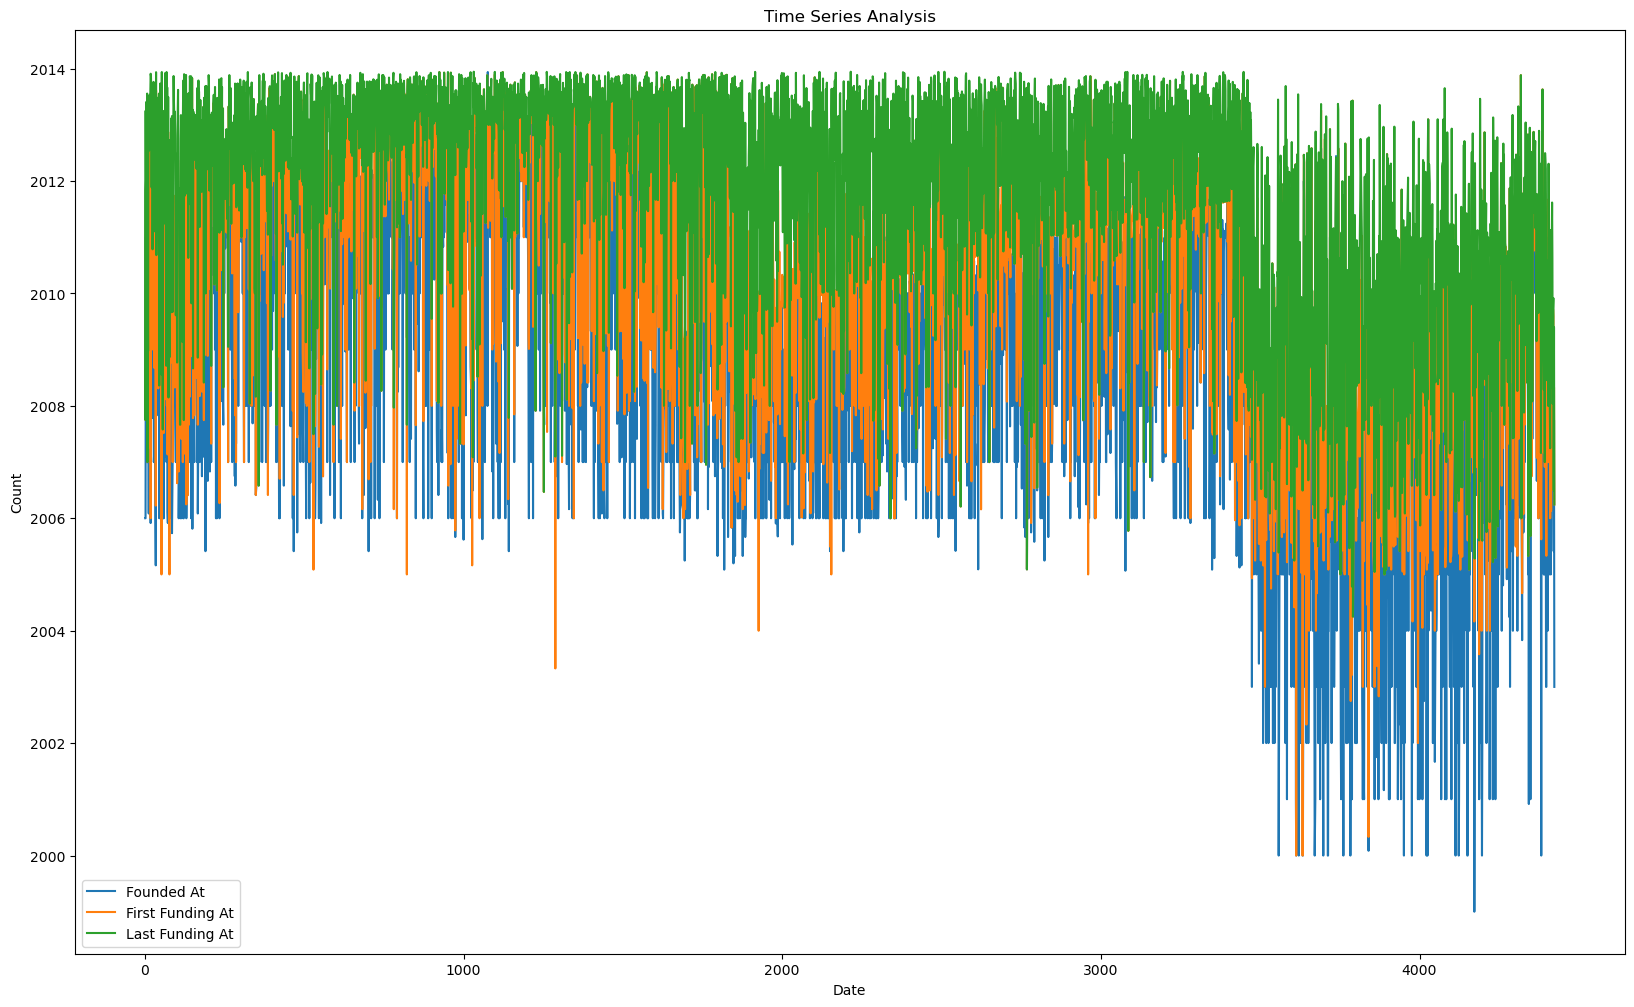

/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/691570140.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_without_outliers['funding_duration_first'] = (data_without_outliers['first_funding_at'] - data_without_outliers['founded_at']).dt.days
/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/691570140.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_without_outliers['funding_duration_last'] = (data_without_outliers['last_funding_at'] - data_without_outliers['

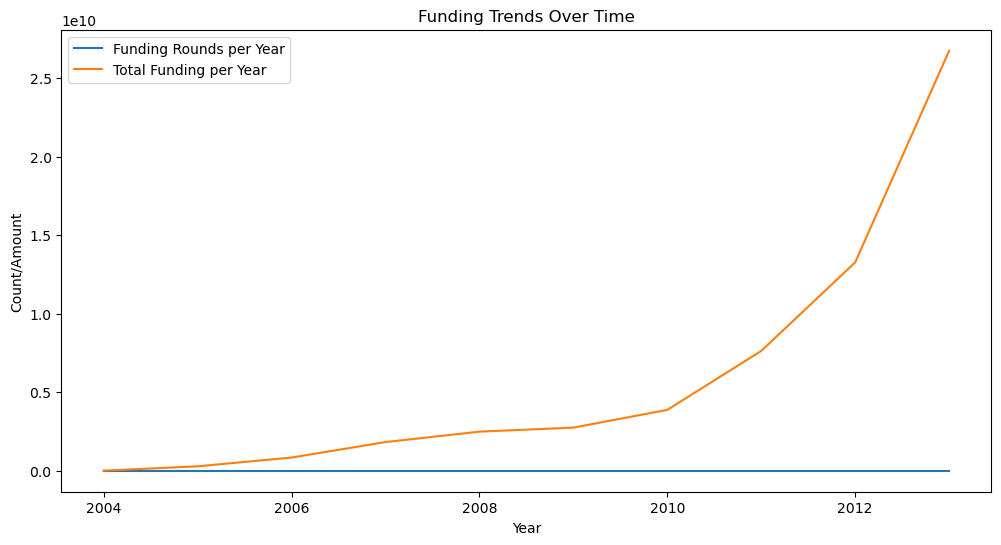

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

data_without_outliers['founded_at'] = pd.to_datetime(data_without_outliers['founded_at'])
data_without_outliers['first_funding_at'] = pd.to_datetime(data_without_outliers['first_funding_at'])
data_without_outliers['last_funding_at'] = pd.to_datetime(data_without_outliers['last_funding_at'])

plt.figure(figsize=(20, 12))
plt.plot(data_without_outliers['founded_at'], label='Founded At')
plt.plot(data_without_outliers['first_funding_at'], label='First Funding At')
plt.plot(data_without_outliers['last_funding_at'], label='Last Funding At')
plt.title('Time Series Analysis')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.show()

data_without_outliers['funding_duration_first'] = (data_without_outliers['first_funding_at'] - data_without_outliers['founded_at']).dt.days
data_without_outliers['funding_duration_last'] = (data_without_outliers['last_funding_at'] - data_without_outliers['founded_at']).dt.days

funding_rounds_per_year = data_without_outliers['last_funding_at'].dt.year.value_counts().sort_index()
total_funding_per_year = data_without_outliers.groupby(data_without_outliers['last_funding_at'].dt.year)['funding_total_usd'].sum()

plt.figure(figsize=(12, 6))
plt.plot(funding_rounds_per_year.index, funding_rounds_per_year.values, label='Funding Rounds per Year')
plt.plot(total_funding_per_year.index, total_funding_per_year.values, label='Total Funding per Year')
plt.title('Funding Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Count/Amount')
plt.legend()
plt.show()



# EDA 9: Total funding by state and category

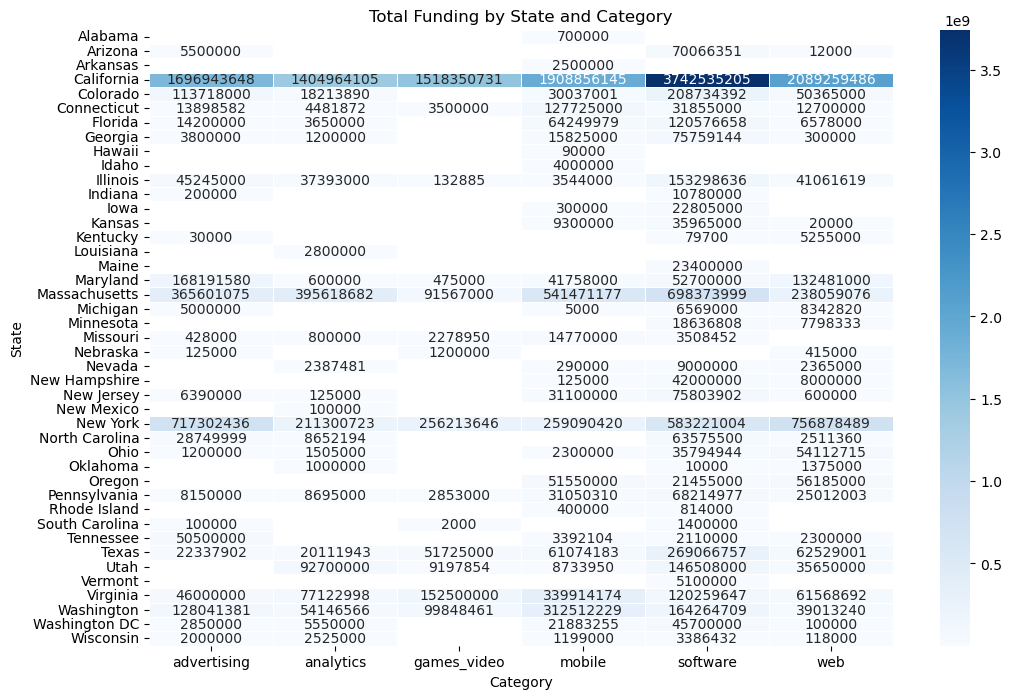

In [31]:
selected_categories = ['analytics', 'web', 'games_video', 'mobile', 'advertising', 'software']
filtered_df = data_without_outliers[data_without_outliers['category_code'].isin(selected_categories)]

grouped_df = filtered_df.groupby(['state', 'category_code'])['funding_total_usd'].sum().reset_index()

pivot_table = grouped_df.pivot(index='state', columns='category_code', values='funding_total_usd')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='Blues', annot=True, fmt='.0f', linewidths=.5)
plt.title('Total Funding by State and Category')
plt.xlabel('Category')
plt.ylabel('State')
plt.show()

# EDA 10: Distribution of Companies Across States by Category and Funding

In [32]:
category_mapping = {
    'analytics': 'Software',
    'web': 'Software',
    'software': 'Software',
    'enterprise': 'Software',
    'ecommerce': 'Software',
    'social': 'Software',
    'network_hosting': 'Software',
    'messaging': 'Software',
    'photo_video': 'Software',
    'search': 'Software',
    'semiconductor': 'Software',
    'design': 'Software',
    'nanotech': 'Software',
    'games_video': 'Software',
    'manufacturing': 'Manufacturing',
    'health': 'Service',
    'advertising': 'Service',
    'hospitality': 'Service',
    'finance': 'Service',
    'public_relations': 'Service',
    'sports': 'Service',
    'music': 'Service',
    'legal': 'Service',
    'education': 'Service',
    'nonprofit': 'Service',
    'news': 'Service',
    'travel': 'Service',
    'automotive': 'Service',
    'medical': 'Service',
    'pets': 'Service',
    'security': 'Service',
    'hardware': 'Hardware',
    'consulting': 'Business',
    'other': 'Business',
    'cleantech': 'Business',
    'fashion': 'Business',
    'real_estate': 'Business',
    'transportation': 'Business',
    'local': 'Business'
}

data_without_outliers['broad_category'] = data_without_outliers['category_code'].map(category_mapping)

/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/1694177030.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_without_outliers['broad_category'] = data_without_outliers['category_code'].map(category_mapping)


/var/folders/c2/nwxtcr753tsc22h494x09qth0000gn/T/ipykernel_12768/2740472964.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_without_outliers['funding_category'] = pd.cut(data_without_outliers['funding_total_usd'],


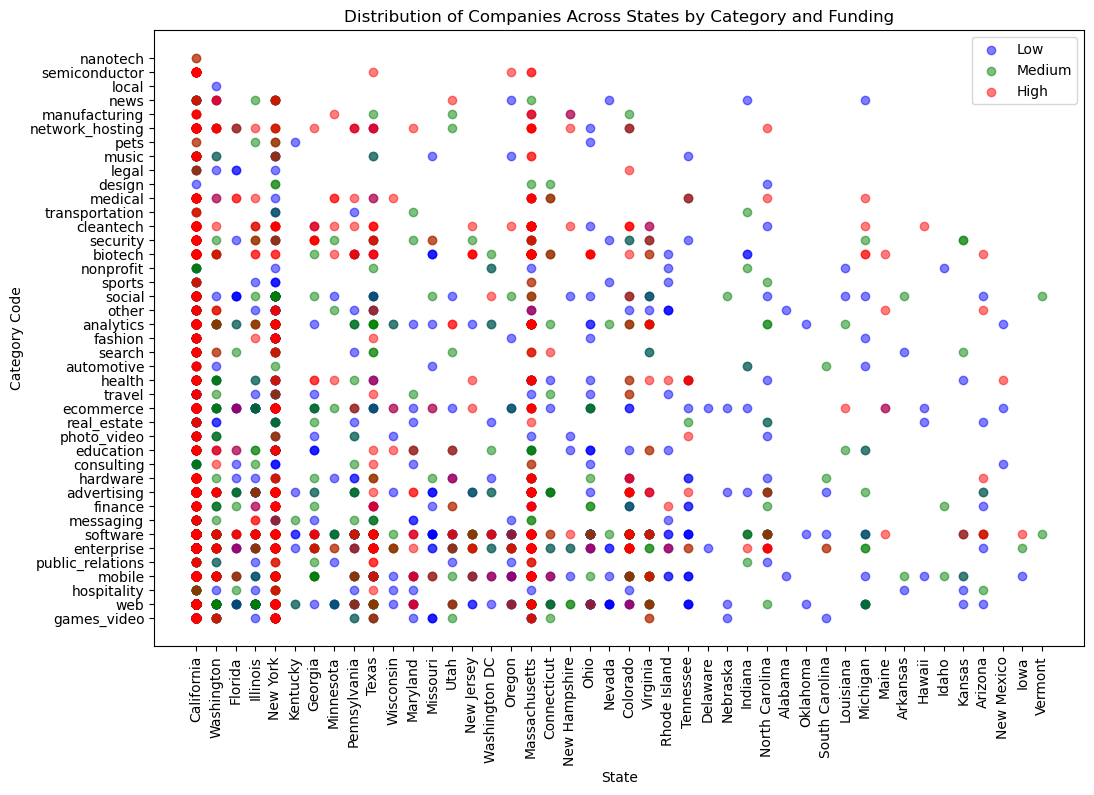

In [33]:
low_threshold = data_without_outliers['funding_total_usd'].quantile(0.33)
high_threshold = data_without_outliers['funding_total_usd'].quantile(0.66)

data_without_outliers['funding_category'] = pd.cut(data_without_outliers['funding_total_usd'],
                                                   bins=[0, low_threshold, high_threshold, float('inf')],
                                                   labels=['Low', 'Medium', 'High'])

colors = {'Low': 'blue', 'Medium': 'green', 'High': 'red'}

plt.figure(figsize=(12, 8))
for category, color in colors.items():
    category_data = data_without_outliers[data_without_outliers['funding_category'] == category]
    plt.scatter(category_data['state'], category_data['category_code'], c=color, label=category, alpha=0.5)

plt.title('Distribution of Companies Across States by Category and Funding')
plt.xlabel('State')
plt.ylabel('Category Code')
plt.legend()
plt.xticks(rotation=90)
plt.show()

# EDA 11: Dataframe shape

In [34]:
print(data_without_outliers.shape)

(4049, 31)
